In [1]:
import pandas as pd
import re
import ftfy
import html
import unicodedata
from rapidfuzz import fuzz
from collections import Counter

# =====================================
# CONFIG
# =====================================

INPUT_PATH = "dataset/untidar_raw.csv"

OUTPUT_ANALYSIS = "dataset/break/dataset_step1_break_analysis1.csv"
OUTPUT_STATS = "dataset/break/break_stats.txt"

TEXT_COL = "Abstrak_Raw"

FUZZY_THRESHOLD = 80

# =====================================
# NORMALIZER
# =====================================

def normalize(text):

    if pd.isna(text):
        return ""

    text = str(text)

    text = ftfy.fix_text(text)
    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)

    text = text.lower()

    text = re.sub(r"\s+", " ", text)

    return text.strip()


# =====================================
# DETECTORS
# =====================================



HEADER_RE = re.compile(
    r'^\s*["\']?\s*'
    r'(abstrak|abstract|intisari|ringkasan)'
    r'\s*$',
    re.I
)

KEYWORD_RE = re.compile(
    r'^(kata\s*kunci|keywords?|key\s*words?)\s*:',
    re.I
)

META_RE = re.compile(
    r'''
    undergraduate\s+thesis|
    bachelor\s+thesis|
    first\s+advisor|
    second\s+advisor|
    faculty\s+of|
    department|
    universitas|
    universiti|
    supervised\s+by|
    pembimbing|
    dosen\s+pembimbing|
    program\s+studi|
    fakultas
    ''',
    re.I | re.VERBOSE
)

YEAR_RE = re.compile(r"\b(19|20)\d{2}\b")


# =====================================
# FUZZY BLOCK CHECK
# =====================================

def is_metadata_match(block, row):

    block_norm = normalize(block)

    candidates = [
        row.get("Judul"),
        row.get("Penulis"),
        row.get("Fakultas"),
        row.get("Prodi")
    ]

    max_score = 0

    for c in candidates:

        if pd.isna(c):
            continue

        score = fuzz.partial_ratio(
            normalize(c),
            block_norm
        )

        max_score = max(max_score, score)

    return max_score >= FUZZY_THRESHOLD, max_score


# =====================================
# LOAD DATA
# =====================================

df = pd.read_csv(
    INPUT_PATH,
    sep="|",
    encoding="utf-8",
    on_bad_lines="skip"
)

print(f"Loaded {len(df):,} rows")

# =====================================
# ANALYSIS
# =====================================

rows = []

block_counter = Counter()

for idx, row in df.iterrows():

    doc_id = row.get("DocID")

    text = row.get(TEXT_COL)

    if pd.isna(text):
        continue

    text = str(text)

    blocks = [
        x.strip()
        for x in text.split("<BR>")
        if x.strip()
    ]

    for block_no, block in enumerate(blocks, start=1):

        block_norm = normalize(block)

        is_header = bool(
            HEADER_RE.match(block_norm)
        )

        is_keyword = bool(
            KEYWORD_RE.match(block_norm)
        )

        is_meta_pattern = bool(
            META_RE.search(block_norm)
        )

        is_year_only = bool(
            YEAR_RE.fullmatch(block_norm)
        )

        fuzzy_match, fuzzy_score = is_metadata_match(
            block,
            row
        )

        rows.append({

            "DocID": doc_id,

            "Block_No": block_no,

            "Block_Text": block,

            "Block_Length": len(block),

            "Word_Count": len(block.split()),

            "Is_Header": is_header,

            "Is_Keyword": is_keyword,

            "Is_MetadataPattern": is_meta_pattern,

            "Is_MetadataMatch": fuzzy_match,

            "Metadata_Score": fuzzy_score,

            "Is_YearOnly": is_year_only
        })

        block_counter[block_norm] += 1

    if idx % 500 == 0:
        print(
            f"{idx:,}/{len(df):,}"
        )

# =====================================
# SAVE ANALYSIS
# =====================================

analysis_df = pd.DataFrame(rows)

analysis_df.to_csv(
    OUTPUT_ANALYSIS,
    index=False,
    encoding="utf-8"
)

print(
    f"\nSaved:\n{OUTPUT_ANALYSIS}"
)

# =====================================
# TOP BLOCKS
# =====================================

top_blocks = pd.DataFrame(
    block_counter.most_common(200),
    columns=[
        "Block_Text",
        "Frequency"
    ]
)

# =====================================
# STATS
# =====================================

with open(
    OUTPUT_STATS,
    "w",
    encoding="utf-8"
) as f:

    f.write("==== BREAK ANALYSIS ====\n\n")

    f.write(
        f"Rows: {len(df):,}\n"
    )

    f.write(
        f"Blocks: {len(analysis_df):,}\n\n"
    )

    f.write(
        f"Headers: {analysis_df['Is_Header'].sum():,}\n"
    )

    f.write(
        f"Keywords: {analysis_df['Is_Keyword'].sum():,}\n"
    )

    f.write(
        f"MetadataPattern: {analysis_df['Is_MetadataPattern'].sum():,}\n"
    )

    f.write(
        f"MetadataMatch: {analysis_df['Is_MetadataMatch'].sum():,}\n\n"
    )

    f.write(
        "===== TOP 200 BLOCKS =====\n\n"
    )

    for _, r in top_blocks.iterrows():

        f.write(
            f"[{r['Frequency']}] "
            f"{r['Block_Text'][:500]}\n"
        )

print(
    f"Saved:\n{OUTPUT_STATS}"
)

# =====================================
# QUICK SUMMARY
# =====================================

print("\n===== SUMMARY =====")

print(
    "Headers:",
    analysis_df["Is_Header"].sum()
)

print(
    "Keywords:",
    analysis_df["Is_Keyword"].sum()
)

print(
    "MetadataPattern:",
    analysis_df["Is_MetadataPattern"].sum()
)

print(
    "MetadataMatch:",
    analysis_df["Is_MetadataMatch"].sum()
)

print(
    "\nTop recurring blocks:"
)

print(
    top_blocks.head(20)
)

Loaded 7,620 rows
0/7,620
500/7,620
1,000/7,620
1,500/7,620
2,000/7,620
2,500/7,620
3,000/7,620
3,500/7,620
4,000/7,620
4,500/7,620
5,000/7,620
5,500/7,620
6,000/7,620
6,500/7,620
7,000/7,620
7,500/7,620

Saved:
dataset/break/dataset_step1_break_analysis1.csv
Saved:
dataset/break/break_stats.txt

===== SUMMARY =====
Headers: 3736
Keywords: 3353
MetadataPattern: 1359
MetadataMatch: 5771

Top recurring blocks:
                                           Block_Text  Frequency
0                                             abstrak       2586
1                            tidak tersedia deskripsi       1065
2                                            abstract        558
3                                            intisari        538
4                                           abstraksi        112
5                                   2. hipotesa minor        101
6                                   1. hipotesa mayor         94
7                                  1. hipotesa mayor.         61
8  

In [16]:
import pandas as pd
import re
import ftfy
import html
import unicodedata
from rapidfuzz import fuzz

# Lang detect untuk medeteksi bahasa 
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

# ==========================================
# CONFIG
# ==========================================

INPUT_PATH = "dataset/untidar_raw.csv"
OUTPUT_PATH = "dataset/dataset_step2_cleaned.csv"

TEXT_COL = "Abstrak_Raw"
FUZZY_THRESHOLD = 95

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv(
    INPUT_PATH,
    sep="|",
    encoding="utf-8",
    on_bad_lines="skip"
)

# ==========================================
# YEAR FILTER
# ==========================================

YEAR_COL = "Tahun"   # ganti kalau nama kolom berbeda
MIN_YEAR = 2023

if YEAR_COL in df.columns:

    df[YEAR_COL] = (
        df[YEAR_COL]
        .astype(str)
        .str.extract(r'(\d{4})')[0]
    )

    df[YEAR_COL] = (
        pd.to_numeric(df[YEAR_COL], errors="coerce")
        .round()
        .astype("Int64")
    )

    print("\nDistribusi Tahun Sebelum Filter")
    print(df[YEAR_COL].value_counts().sort_index())

    df = df[
        df[YEAR_COL] >= MIN_YEAR
    ].copy()

    print("\nDistribusi Tahun Setelah Filter")
    print(df[YEAR_COL].value_counts().sort_index())

    print("Rows setelah filter tahun:", len(df))

else:
    print(f"WARNING: Kolom '{YEAR_COL}' tidak ditemukan")
    print(df.columns.tolist())


# ==========================================
# REMOVE EMPTY ABSTRACTS
# ==========================================

df = df[
    ~df[TEXT_COL]
    .fillna("")
    .str.lower()
    .str.contains("tidak tersedia deskripsi", na=False)
].copy()

# ==========================================
# CEK SANITASI
# ==========================================
def looks_like_real_abstract(block):

    words = len(block.split())

    if words >= 60:
        return True

    ABSTRACT_HINTS = [
        "penelitian",
        "bertujuan",
        "hasil",
        "metode",
        "analisis",
        "menunjukkan",
        "menggunakan",
        "dilakukan",
        "responden",
        "data"
    ]

    text = normalize(block)

    hits = sum(
        h in text
        for h in ABSTRACT_HINTS
    )

    return hits >= 2

# ==========================================
# REGEX
# ==========================================

EMAIL_RE = re.compile(r"[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+")

HEADER_WORDS = {
    "abstrak", "abstract", "intisari",
    "ringkasan", "abstraksi", "abstrac", "abstrack"
}

KEYWORD_RE = re.compile(r"^(kata\s*kunci|keywords?|key\s*words?)\s*:", re.I)

METADATA_RE = re.compile(
    r"""
    universitas|fakultas|program\s*studi|jurusan|
    undergraduate|bachelor|thesis|skripsi|
    advisor|pembimbing|faculty|department
    """,
    re.I | re.X
)

SHORT_TRASH_RE = re.compile(r"^(\d+|[ivxlcdm]+|\-|.|…)$", re.I)

# ==========================================
# SUPERVISOR DETECTION (BRUTE FORCE CORE)
# ==========================================

SUPERVISOR_KEYWORD_RE = re.compile(
    r"(dibimbing\s+oleh|pembimbing|dosen\s+pembimbing|advisor)",
    re.I
)

SUPERVISOR_BLOCK_BRUTE_RE = re.compile(
    r"""
    (dibimbing\s+oleh|pembimbing|dosen\s+pembimbing|advisor)
    .*?
    ([A-Z][a-z]+(?:\s+[A-Z][a-z]+){1,}\s*,\s*(S\.|M\.))
    .*?
    (dan|&)
    .*?
    ([A-Z][a-z]+(?:\s+[A-Z][a-z]+){1,}\s*,\s*(S\.|M\.))
    """,
    re.I | re.X
)

def is_supervisor_heavy_block(text: str) -> bool:
    if not isinstance(text, str):
        return False

    has_titles = len(re.findall(r",\s*(S\.|M\.)", text)) >= 2
    has_and = " dan " in text.lower()

    return has_titles and has_and

# ==========================================
# CLEANING HELPERS
# ==========================================
# Drop Duplicate
# Simpan baris terakhir

def normalize(text):
    if not isinstance(text, str):
        return ""

    text = ftfy.fix_text(text)
    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)

    text = text.lower()
    text = re.sub(r"\s+", " ", text)

    return text.strip()


def strip_supervisor_only(text: str) -> str:
    if not isinstance(text, str):
        return ""

    return re.sub(
        r"(dibimbing\s+oleh|pembimbing\s*[:\-]|dosen\s+pembimbing|advisor)\s*",
        "",
        text,
        flags=re.I
    ).strip()


def strip_academic_names(text: str) -> str:
    return re.sub(
        r"[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*,\s*(S\.|M\.)[A-Za-z\.,\s]*",
        "",
        text
    ).strip()


def clean_block_prefix(block: str) -> str:
    if not isinstance(block, str):
        return ""

    block = EMAIL_RE.sub(" ", block)

    block = re.sub(
        r"^\s*(abstrak|abstract|intisari|ringkasan)\s*[:\-]?\s*",
        "",
        block,
        flags=re.I
    )

    block = re.sub(r"^[A-Z\s\.,]{5,}\.\s*", "", block)

    return re.sub(r"\s+", " ", block).strip()

# ==========================================
# FUZZY METADATA
# ==========================================

def is_fuzzy_metadata(block, noise_list):
    b = normalize(block)

    for n in noise_list:
        if isinstance(n, str):
            if fuzz.partial_ratio(normalize(n), b) >= FUZZY_THRESHOLD:
                return True
    return False


def build_noise(row):
    return [
        str(row[c])
        for c in ["Judul", "Penulis", "Fakultas", "Prodi"]
        if c in row and pd.notna(row[c])
    ]

# ==========================================
# SENTENCE COUNT
# ==========================================

def count_sentences(text):
    if not isinstance(text, str):
        return 0
    return len([s for s in re.split(r"[.!?]+", text) if s.strip()])

# ==========================================
# MAIN CLEANER
# ==========================================

# SAFE METADATA CHECK

def is_pure_metadata(block):

    text = normalize(block)

    # metadata biasanya pendek
    if len(text.split()) > 20:
        return False

    return bool(
        METADATA_RE.search(text)
    )

def clean_row(row):

    text = row.get(TEXT_COL)

    if not isinstance(text, str):
        return pd.Series({
            "Paragraf": "",
            "Keyword_Text": "",
            "Has_Keyword": False,
            "Removed_Header": 0,
            "Removed_Keyword": 0,
            "Removed_Metadata": 0,
            "Removed_Fuzzy": 0,
            "Removed_Garbage": 0,
            "BR_Count": 0,
            "Word_Count": 0,
            "Sentence_Count": 0
        })

    text = ftfy.fix_text(text)
    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)

    # quote setelah separator
    text = re.sub(r'(?<=\|)\s*"', '', text)

    # quote sebelum separator
    text = re.sub(r'"\s*(?=\|)', '', text)

    blocks = [
        clean_block_prefix(b.strip())
        for b in text.split("<BR>")
        if b.strip()
    ]

    blocks, removed_title_author = (
        remove_title_author_block(
            blocks,
            row
        )
    )

    noise = build_noise(row)

    clean_blocks = []
    keywords = []

    removed_header = 0
    removed_keyword = 0
    removed_metadata = 0
    removed_fuzzy = 0
    removed_garbage = 0

    for b in blocks:

        # =========================
        # SAFE EDIT LAYER
        # =========================

        b = strip_supervisor_only(b)
        b = strip_academic_names(b)

        # BRUTE FORCE SUPERVISOR KILL
        if SUPERVISOR_BLOCK_BRUTE_RE.search(b) or is_supervisor_heavy_block(b):
            removed_metadata += 1
            continue

        b_norm = normalize(b)

        if b_norm in {"tidak tersedia deskripsi", "tidak ada abstrak", "-", "...", "."}:
            removed_garbage += 1
            continue

        if b_norm in HEADER_WORDS:
            removed_header += 1
            continue

        if KEYWORD_RE.match(b):
            keywords.append(b)
            removed_keyword += 1
            continue

        if SHORT_TRASH_RE.match(b_norm):
            removed_garbage += 1
            continue

        if len(b.strip()) < 5:
            removed_garbage += 1
            continue
        
        # =====================================
        # TITLE MATCH CHECK - MOVED HERE
        # =====================================

        title = str(
            row.get("Judul", "")
        )

        title_sim = fuzz.partial_ratio(
            normalize(title),
            normalize(b)
        )

        # metadata pendek yang mirip judul
        if (
            title_sim >= 95
            and len(b.split()) < 40
        ):
            removed_fuzzy += 1
            continue

        # metadata pendek saja
        if is_pure_metadata(b):
            removed_metadata += 1
            continue

        # fuzzy metadata
        if is_fuzzy_metadata(b, noise):

            # abstrak asli jangan dibuang
            if not looks_like_real_abstract(b):

                removed_fuzzy += 1
                continue

        clean_blocks.append(b)

    paragraf = " ".join(clean_blocks)
    paragraf = re.sub(r"\s+", " ", paragraf).strip()

    return pd.Series({
        "Paragraf": paragraf,
        "Keyword_Text": " | ".join(keywords),
        "Has_Keyword": len(keywords) > 0,

        "Removed_Header": removed_header,
        "Removed_Keyword": removed_keyword,
        "Removed_Metadata": removed_metadata,
        "Removed_Fuzzy": removed_fuzzy,
        "Removed_Garbage": removed_garbage,

        "BR_Count": len(blocks),
        "Word_Count": len(paragraf.split()),
        "Sentence_Count": count_sentences(paragraf),
        "Removed_TitleAuthor": removed_title_author,
    })


# ==========================================
# LANGUAGE DETECTION
# ==========================================

def detect_language(text):

    if not isinstance(text, str):
        return "OTHER"

    text = text.strip()

    if len(text) < 30:
        return "OTHER"

    lower = text.lower()

    if "abstrak" in lower and "abstract" in lower:
        return "MIXED"

    try:

        lang = detect(text)

        if lang == "id":
            return "ID"

        if lang == "en":
            return "EN"

        return "OTHER"

    except:
        return "OTHER"


def remove_title_author_block(blocks, row):

    if len(blocks) < 2:
        return blocks, 0

    title = str(
        row.get("Judul", "")
    )

    author = str(
        row.get("Penulis", "")
    )

    title_norm = normalize(title)
    author_norm = normalize(author)

    removed = 0
    keep = []

    for block in blocks:

        b_norm = normalize(block)

        # ==========================
        # AUTHOR
        # ==========================

        if author_norm:

            score = fuzz.partial_ratio(
                author_norm,
                b_norm
            )

            if score >= 90:
                removed += 1
                continue

        # ==========================
        # TITLE
        # ==========================

        title_score = 0

        if title_norm:

            title_score = fuzz.partial_ratio(
                title_norm,
                b_norm
            )

        if title_score >= 75:

            word_count = len(
                b_norm.split()
            )

            if word_count <= 40:
                removed += 1
                continue

        # ==========================
        # DIBIMBING OLEH
        # ==========================

        if re.search(
            r'dibimbing\s+oleh',
            b_norm,
            flags=re.I
        ):
            removed += 1
            continue

        keep.append(block)

    return keep, removed
# ==========================================
# PROCESS
# ==========================================

cleaned = df.apply(clean_row, axis=1)
df = pd.concat([df, cleaned], axis=1)

df = df[df["Word_Count"] >= 20].reset_index(drop=True)

# ==========================================
# LANGUAGE LABEL
# ==========================================

print("\nDetecting language...")

df["Language"] = df["Paragraf"].apply(
    detect_language
)

print("\nLanguage Distribution")
print(df["Language"].value_counts())

# ==========================================
# FORMAT OUTPUT
# ==========================================

df = df.drop(columns=[TEXT_COL])

cols = list(df.columns)
cols.remove("Paragraf")
cols.insert(cols.index("DocID") + 1, "Paragraf")

df = df[cols]

print("\n========== DATASET SUMMARY ==========")

print("Rows:", len(df))

print(
    "Avg Words:",
    round(df["Word_Count"].mean(), 2)
)

print(
    "Avg Sentences:",
    round(df["Sentence_Count"].mean(), 2)
)

print("\nLanguage Distribution")
print(df["Language"].value_counts())

# ==========================================
# SAVE
# ==========================================

df.to_csv(OUTPUT_PATH, sep="|", index=False, encoding="utf-8")

print("CLEANING COMPLETE")
print("Rows:", len(df))
print("Avg words:", df["Word_Count"].mean())


Distribusi Tahun Sebelum Filter
Tahun
1898       1
1978       1
1982       9
1983      15
1984       1
1985       2
1986       5
1987      25
1988      66
1989      69
1990      90
1991     107
1992     114
1993     119
1994     128
1995     141
1996     208
1997      67
1998      86
1999      82
2000     175
2001     304
2002     227
2003     185
2004     196
2005      76
2006     142
2007      69
2008      93
2009      43
2010      24
2011      12
2012       1
2013       7
2014       6
2015       7
2017       2
2019       1
2021       1
2022       1
2023      93
2024    1797
2025    2322
2026     419
Name: count, dtype: Int64

Distribusi Tahun Setelah Filter
Tahun
2023      93
2024    1797
2025    2322
2026     419
Name: count, dtype: Int64
Rows setelah filter tahun: 4631

Detecting language...

Language Distribution
Language
ID       3852
EN        298
MIXED       2
Name: count, dtype: int64

========== DATASET SUMMARY ==========
Rows: 4152
Avg Words: 205.14
Avg Sentences: 10.98

L

In [17]:
# ======================================
# CLEAN DATA AUDIT
# ======================================

print("="*60)
print("CLEAN DATA AUDIT")
print("="*60)

print("Dokumen :", len(df))
print("Kata    :", f"{df['Word_Count'].sum():,}")
print("Kalimat :", f"{df['Sentence_Count'].sum():,}")

print("\nWORD COUNT")

print(
    df["Word_Count"].describe()
)

print("\nSENTENCE COUNT")

print(
    df["Sentence_Count"].describe()
)

print("\nTOP 10 DOKUMEN TERPANJANG")

display(
    df.nlargest(
        10,
        "Word_Count"
    )[[
        "DocID",
        "Tahun",
        "Word_Count",
        "Sentence_Count",
        "Judul"
    ]]
)

print("\nTOP 10 DOKUMEN TERPENDEK")
display(
    df.nsmallest(
        10,
        "Word_Count"
    )[[
        "DocID",
        "Tahun",
        "Word_Count",
        "Sentence_Count",
        "Judul"
    ]]
)

CLEAN DATA AUDIT
Dokumen : 4152
Kata    : 851,745
Kalimat : 45,593

WORD COUNT
count    4152.000000
mean      205.140896
std        65.425425
min        29.000000
25%       167.000000
50%       199.500000
75%       237.000000
max       681.000000
Name: Word_Count, dtype: float64

SENTENCE COUNT
count    4152.000000
mean       10.980973
std         4.387009
min         2.000000
25%         8.000000
50%        10.000000
75%        13.000000
max        45.000000
Name: Sentence_Count, dtype: float64

TOP 10 DOKUMEN TERPANJANG


,DocID,Tahun,Word_Count,Sentence_Count,Judul
3212,20267,2025,681,24,SKRIPSI PENGEMBANGAN BUKU PETUNJUK PRAKTIKUM B...
377,16015,2024,619,32,SKRIPSI ANALISIS PENGARUH VARIASI BAHAN DRUM T...
370,16008,2024,532,32,SKRIPSI COMPUTATIONAL ANALYSIS PERFORMA TURBIN...
1082,16837,2024,517,27,SKRIPSI CODE-SWITCHING USED IN ENGLISH TEACHER...
662,16357,2024,487,21,SKRIPSI EFEKTIVITAS MODEL COOPERATIVE LEARNING...
1616,17949,2025,470,18,PENGARUH MODEL PEMBELAJARAN PROBLEM BASED LEAR...
3210,20265,2025,452,23,SKRIPSI PENGEMBANGAN MODUL IPA SMP TEMA â€œSIS...
3976,22027,2026,450,21,SKRIPSI PENGARUH METODE MAKE A MATCH DAN JIGSA...
206,15811,2024,441,25,SKRIPSI INVESTIGATING LANGUAGE TESTING AND ASS...
2674,19613,2025,441,12,SKRIPSI EFEKTIVITAS MODEL PROBLEM BASED LEARNI...



TOP 10 DOKUMEN TERPENDEK


,DocID,Tahun,Word_Count,Sentence_Count,Judul
1339,17206,2024,29,2,SKRIPSI PENGARUH MIDNIGHT FEEDING TERHADAP FEE...
606,16261,2024,30,6,SKRIPSI STUDI ETNOZOOLOGI AYAM CEMANI DI KECAM...
616,16275,2024,30,5,SKRIPSI STUDI ETNOBOTANI KEARIFAN LOKAL PADA T...
617,16277,2024,30,5,SKRIPSI PENGARUH PENERAPAN GAME BASED LEARNING...
1070,16824,2024,30,5,SKRIPSI IMPROVING THE STUDENTSâ€™ WRITING SKIL...
1126,16901,2024,30,5,SKRIPSI PENGEMBANGAN E-MODUL BERBASIS ETNOMATE...
1290,17135,2024,30,6,SKRIPSI IDENTIFIKASI TUMBUHAN ANGIOSPERMAE BER...
1461,17764,2024,30,4,SKRIPSI USING CAKE APPLICATION TO IMPROVE SPEA...
177,15775,2024,31,6,SKRIPSI PENGEMBANGAN BOOKLET BERBASIS IDENTIFI...
279,15907,2024,31,5,SKRIPSI PENGARUH MODEL PEMBELAJARAN ROTATING T...


In [15]:
audit = []

for _, row in df.iterrows():

    raw_words = len(
        str(row["Paragraf"]).split()
    )

    clean_words = row["Word_Count"]

    ratio = clean_words / max(raw_words, 1)

    if ratio < 0.25:

        audit.append({
            "DocID": row["DocID"],
            "Ratio": ratio,
            "CleanWords": clean_words,
            "RawWords": raw_words,
            "Judul": row["Judul"]
        })

audit = pd.DataFrame(audit)

print(audit.shape)

(0, 0)



===== LANGUAGE DISTRIBUTION =====
Language
ID       3258
EN        220
MIXED      10
OTHER       4
Name: count, dtype: int64


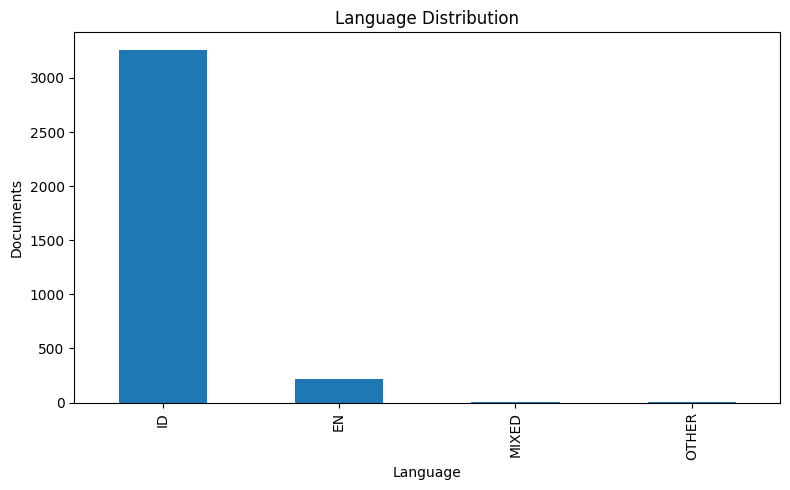

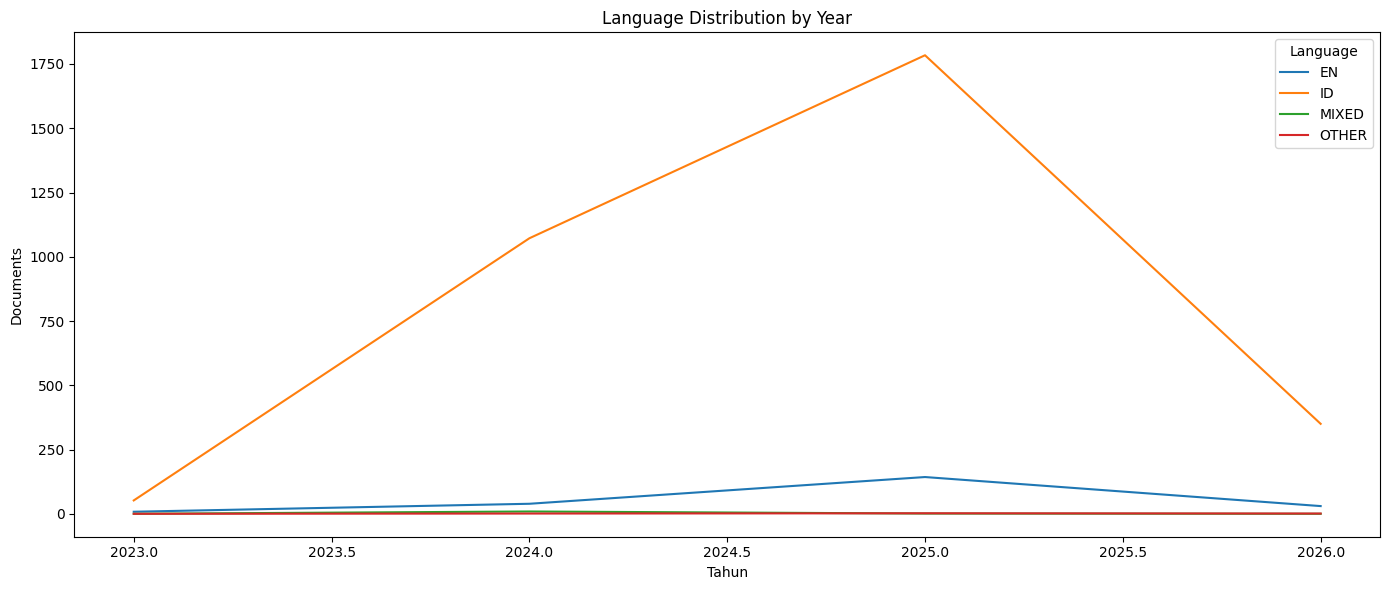


===== SAMPLE EN =====


,DocID,Tahun,Judul
19,15553,2024,SKRIPSI INVESTIGATING EMOTIVE LANGUAGE IN READ...
20,15554,2024,SKRIPSI UTILIZING VIDEO PROJECTS TO ENHANCE TH...
21,15556,2024,SKRIPSI USING NINOâ€™S HOME VIDEOS TO IMPROVE ...
22,15558,2024,SKRIPSI EXPLORING THE IMPLEMENTATION OF BLENDE...
23,15565,2024,SKRIPSI THE EFFECTIVENESS OF USING EXAMPLE NON...
24,15567,2024,SKRIPSI INVESTIGATING ENGLISH READING SKILLS O...
25,15568,2024,SKRIPSI THE EFFECTIVENESS OF USING DIGITAL STO...
26,15569,2024,SKRIPSI THE CORRELATION BETWEEN THE VOCABULARY...
27,15570,2024,SKRIPSI CLAUSE COMPLEX STRUCTURES IN READING T...
28,15571,2024,SKRIPSI CLASSROOM MANAGEMENT PROBLEMS IN TEACH...



===== SAMPLE MIXED =====


,DocID,Tahun,Judul
2,15004,2024,SKRIPSI KAJI EKSPERIMENTAL PENGARUH VARIASI SU...
8,15487,2024,SKRIPSI DETEKSI PENYAKIT DAUN DURIAN DENGAN AL...
11,15495,2024,SKRIPSI IMPLEMENTASI FUZZY LOGIC CONTROLLER PA...
293,15987,2024,SKRIPSI OPTIMASI DESAIN SHELL AND TUBE HEAT EX...
303,15999,2024,SKRIPSI PENGARUH KONSENTRASI RAGI DAN DEHIDRAS...
311,16008,2024,SKRIPSI COMPUTATIONAL ANALYSIS PERFORMA TURBIN...
318,16015,2024,SKRIPSI ANALISIS PENGARUH VARIASI BAHAN DRUM T...
319,16016,2024,SKRIPSI PERHITUNGAN UMUR PAKAI LAPISAN TEFLON ...
373,16078,2024,SKRIPSI ANALISIS SINYAL ELECTROENCEPHALOGRAM M...
1549,18321,2025,"SKRIPSI PENGARUH MODEL PEMBELAJARAN ACTIVITY, ..."



===== PERCENT =====
Language
ID       93.30
EN        6.30
MIXED     0.29
OTHER     0.11
Name: proportion, dtype: float64


In [4]:
# ==========================================
# LANGUAGE DETECTION (ROBUST VERSION)
# ==========================================

import re
import pandas as pd
import matplotlib.pyplot as plt

from lingua import (
    Language,
    LanguageDetectorBuilder
)

# ==========================================
# MARKERS
# ==========================================

ID_MARKERS = {
    "yang","dan","dengan","untuk","pada",
    "dalam","adalah","penelitian",
    "hasil","metode","dapat","terhadap",
    "karena","oleh","ini","tersebut",
    "bahwa","sebagai","akan","telah",
    "menggunakan","berdasarkan",
    "pengaruh","analisis","kesimpulan",
    "tujuan","responden","sampel",
    "variabel","hipotesis",
    "peneliti","diperoleh",
    "menunjukkan","terdapat",
    "penelitian","pengujian",
    "pendekatan","data",
    "maka","sehingga",
    "kecamatan","kabupaten"
}

EN_MARKERS = {
    "the","and","with","for","that",
    "this","research","study","results",
    "method","using","can","were",
    "from","into","between",
    "analysis","sample","respondents",
    "variable","variables",
    "conclusion","objective",
    "effect","influence",
    "significant","data",
    "based","using","approach",
    "model","testing",
    "performance","accuracy"
}

# ==========================================
# DETECTOR
# ==========================================

detector = (
    LanguageDetectorBuilder
    .from_languages(
        Language.INDONESIAN,
        Language.ENGLISH
    )
    .build()
)

# ==========================================
# ROBUST DETECTOR
# ==========================================

def robust_language(text):

    if not isinstance(text, str):
        return "OTHER"

    text = text.strip()

    if len(text) < 100:
        return "OTHER"

    words = re.findall(
        r"[a-z]+",
        text.lower()
    )

    if len(words) < 30:
        return "OTHER"

    # -------------------
    # Marker Count
    # -------------------

    id_hits = sum(
        w in ID_MARKERS
        for w in words
    )

    en_hits = sum(
        w in EN_MARKERS
        for w in words
    )

    # -------------------
    # Lingua
    # -------------------

    try:

        lang = detector.detect_language_of(text)

        confidence = detector.compute_language_confidence_values(text)

        conf = {
            str(x.language): x.value
            for x in confidence
        }

        id_conf = conf.get(
            "INDONESIAN",
            0
        )

        en_conf = conf.get(
            "ENGLISH",
            0
        )

    except:

        lang = None
        id_conf = 0
        en_conf = 0

    # -------------------
    # Rules
    # -------------------

    total_marker = id_hits + en_hits

    if total_marker > 0:

        id_ratio = id_hits / total_marker
        en_ratio = en_hits / total_marker

        if id_ratio >= 0.65:
            return "ID"

        if en_ratio >= 0.65:
            return "EN"

    # Lingua fallback

    if id_conf >= 0.80:
        return "ID"

    if en_conf >= 0.80:
        return "EN"

    if id_conf > en_conf:
        return "ID"

    if en_conf > id_conf:
        return "EN"

    return "MIXED"

# ==========================================
# RUN DETECTION
# ==========================================

df["Language"] = (
    df["Paragraf"]
    .apply(robust_language)
)

# ==========================================
# DISTRIBUTION
# ==========================================

lang_counts = (
    df["Language"]
    .value_counts()
)

print("\n===== LANGUAGE DISTRIBUTION =====")
print(lang_counts)

# ==========================================
# BAR CHART
# ==========================================

plt.figure(figsize=(8,5))

lang_counts.plot(
    kind="bar"
)

plt.title(
    "Language Distribution"
)

plt.ylabel("Documents")
plt.xlabel("Language")

plt.tight_layout()
plt.show()

# ==========================================
# YEAR TREND
# ==========================================

lang_year = pd.crosstab(
    df["Tahun"],
    df["Language"]
)

lang_year.plot(
    figsize=(14,6)
)

plt.title(
    "Language Distribution by Year"
)

plt.ylabel(
    "Documents"
)

plt.tight_layout()
plt.show()

# ==========================================
# AUDIT SAMPLE
# ==========================================

print("\n===== SAMPLE EN =====")

display(
    df.loc[
        df["Language"]=="EN",
        ["DocID","Tahun","Judul"]
    ].head(10)
)

print("\n===== SAMPLE MIXED =====")

display(
    df.loc[
        df["Language"]=="MIXED",
        ["DocID","Tahun","Judul"]
    ].head(10)
)

# ==========================================
# PERCENTAGE
# ==========================================

print("\n===== PERCENT =====")

print(
    (
        df["Language"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

In [5]:
import csv
mask_quote = df["Paragraf"].str.match(
    r'^\s*[\"\']',
    na=False
)

print(
    "Leading quote docs:",
    mask_quote.sum()
)

display(
    df.loc[
        mask_quote,
        ["DocID","Paragraf"]
    ].head(20)
)

# ======================================
# FINAL TEXT NORMALIZATION
# ======================================

def final_normalize_text(text):

    if not isinstance(text, str):
        return ""

    text = text.strip()

    # normalize unicode quotes
    text = text.replace("“", '"')
    text = text.replace("”", '"')
    text = text.replace("‘", "'")
    text = text.replace("’", "'")

    # hapus quote pembungkus awal
    text = re.sub(
        r'^\s*["\']+',
        '',
        text
    )

    # hapus quote pembungkus akhir
    text = re.sub(
        r'["\']+\s*$',
        '',
        text
    )

    # normalisasi titik berlebihan
    text = re.sub(
        r"\.{3,}",
        "...",
        text
    )

    text = re.sub(
        r"\.{2}",
        ".",
        text
    )

    # normalisasi spasi
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

# apply
df["Paragraf"] = (
    df["Paragraf"]
    .apply(final_normalize_text)



)


# ======================================
# SAVE FINAL DATASET
# ======================================

OUTPUT_PATH = "dataset/dataset_step2_cleaned.csv"

df.to_csv(
    OUTPUT_PATH,
    sep="|",
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_MINIMAL,
)

print("\nFINAL DATASET SAVED")
print("Rows :", len(df))
print("Path :", OUTPUT_PATH)

Leading quote docs: 1


,DocID,Paragraf
2437,19931,"""Magelang On Stickers: Kemeceria"" atau disingk..."



FINAL DATASET SAVED
Rows : 3492
Path : dataset/dataset_step2_cleaned.csv


In [6]:
# ====================================
# LANGUAGE CONFIDENCE AUDIT
# ====================================

def language_scores(text):

    words = re.findall(
        r"[a-z]+",
        str(text).lower()
    )

    id_hits = sum(
        w in ID_MARKERS
        for w in words
    )

    en_hits = sum(
        w in EN_MARKERS
        for w in words
    )

    return pd.Series({
        "ID_Hits": id_hits,
        "EN_Hits": en_hits
    })

scores = df["Paragraf"].apply(
    language_scores
)

df = pd.concat(
    [df, scores],
    axis=1
)

# ambil yg tipis banget
borderline = df[
    abs(df["ID_Hits"] - df["EN_Hits"]) <= 3
]

print(
    "Borderline docs:",
    len(borderline)
)

borderline[
    [
        "DocID",
        "Language",
        "ID_Hits",
        "EN_Hits",
        "Judul"
    ]
].head(50)

Borderline docs: 6


,DocID,Language,ID_Hits,EN_Hits,Judul
8,15487,MIXED,42,43,SKRIPSI DETEKSI PENYAKIT DAUN DURIAN DENGAN AL...
11,15495,MIXED,49,47,SKRIPSI IMPLEMENTASI FUZZY LOGIC CONTROLLER PA...
303,15999,MIXED,35,36,SKRIPSI PENGARUH KONSENTRASI RAGI DAN DEHIDRAS...
311,16008,MIXED,47,47,SKRIPSI COMPUTATIONAL ANALYSIS PERFORMA TURBIN...
373,16078,MIXED,29,31,SKRIPSI ANALISIS SINYAL ELECTROENCEPHALOGRAM M...
1549,18321,MIXED,5,3,"SKRIPSI PENGARUH MODEL PEMBELAJARAN ACTIVITY, ..."


In [7]:
# ==========================================
# BUILD FINAL INDONESIAN CORPUS
# ==========================================

df_id = df[
    df["Language"].isin([
        "ID",
        "MIXED"
    ])
].copy()

print("===== FINAL INDONESIAN CORPUS =====")
print("Rows :", len(df_id))

print("\nLanguage Distribution:")
print(
    df_id["Language"]
    .value_counts()
)

print(
    "\nPercent:"
)

print(
    (
        df_id["Language"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

# save
OUTPUT_FINAL = (
    "dataset/dataset_step3_indonesian_only.csv"
)

df_id.to_csv(
    OUTPUT_FINAL,
    sep="|",
    index=False,
    encoding="utf-8"
)

print("\nFINAL DATASET SAVED")
print(OUTPUT_FINAL)

===== FINAL INDONESIAN CORPUS =====
Rows : 3268

Language Distribution:
Language
ID       3258
MIXED      10
Name: count, dtype: int64

Percent:
Language
ID       99.69
MIXED     0.31
Name: proportion, dtype: float64

FINAL DATASET SAVED
dataset/dataset_step3_indonesian_only.csv


In [8]:
df[
    df["Language"] == "ID"
][
    ["DocID","Tahun","Judul","Paragraf"]
].sample(20)

,DocID,Tahun,Judul,Paragraf
1513,18275,2025,SKRIPSI PERBANDINGAN ANTARA EKSEKUSI JAMINAN M...,Tujuan penelitian ini adalah Untuk membandingk...
2364,19843,2025,SKRIPSI PARTISIPASI MASYARAKAT URBAN DALAM PEN...,Pengelolaan sampah di wilayah urban merupakan ...
890,16936,2024,SKRIPSI OPTIMALISASI PADAT TEBAR YANG BERBEDA ...,Penelitian dilaksanakan bulan September sampai...
2891,21309,2025,SKRIPSI VARIABILITAS KINERJA KEUANGAN PADA SEK...,Stategi manajemen melaui implikasi keuangan da...
211,15866,2024,"SKRIPSI PENGARUH KUALITAS LAYANAN, KUALITAS PR...",Penelitian ini dilatarbelakangi oleh semakin m...
3005,21632,2025,SKRIPSI PEMAKNAAN KHALAYAK TERHADAP SULUNG PAD...,"Dalam kehidupan bermasyarakat, urutan kelahira..."
601,16473,2024,"SKRIPSI PENGARUH LIKUIDITAS, LEVERAGE, PROFITA...",Tujuan dari penelitian ini adalah untuk menguj...
2010,19423,2025,SKRIPSI INVESTASI BERKELANJUTAN UNTUK PEMBANGU...,Isu keberlanjutan semakin menjadi fokus utama ...
3139,21795,2026,SKRIPSI PENGARUH MODEL ARGUMENT-DRIVEN INQUIRY...,Pendidikan yang berkualitas menuntut proses pe...
203,15856,2024,"SKRIPSI PENGARUH MOTIVASI KERJA, PENGEMBANGAN ...",Penelitian ini dilakukan pada perusahaan daera...


In [9]:
DOUBLE_DOT_RE = re.compile(r"\.{2,}")

df["double_dot"] = (
    df["Paragraf"]
    .str.count(DOUBLE_DOT_RE)
)

print(
    df["double_dot"].describe()
)

count    3492.000000
mean        0.002864
std         0.063262
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         2.000000
Name: double_dot, dtype: float64


In [10]:
NO_SPACE_AFTER_DOT_RE = re.compile(
    r"[a-z]\.[A-Z]"
)

df["missing_space_after_dot"] = (
    df["Paragraf"]
    .str.count(NO_SPACE_AFTER_DOT_RE)
)

print(
    df["missing_space_after_dot"].describe()
)

count    3492.000000
mean        0.084479
std         0.518376
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        14.000000
Name: missing_space_after_dot, dtype: float64


In [11]:
# sentence length audit

def longest_sentence(text):

    sents = re.split(
        r'(?<=[.!?])\s+',
        str(text)
    )

    if not sents:
        return 0

    return max(
        len(s.split())
        for s in sents
    )

df["Longest_Sentence"] = (
    df["Paragraf"]
    .apply(longest_sentence)
)

print(
    df["Longest_Sentence"]
    .describe()
)

count    3492.000000
mean       38.490836
std        13.668464
min        14.000000
25%        30.000000
50%        35.000000
75%        43.000000
max       144.000000
Name: Longest_Sentence, dtype: float64


In [12]:
sus = df[
    df["missing_space_after_dot"] > 5
]

for _, r in sus.head(20).iterrows():

    print("="*80)
    print("DocID:", r["DocID"])
    print("Count :", r["missing_space_after_dot"])

    hits = re.findall(
        r'.{0,25}[a-z]\.[A-Z].{0,25}',
        r["Paragraf"]
    )

    print(hits[:20])

DocID: 15679
Count : 6
['ada Putusan Nomor 2512/Pid.B/LH/2021/PN Sby. dan Putu', 'san Nomor 582/Pid.Sus-LH/2022/PN Jkt.Sel. Je', 'ada Putusan Nomor 2512/Pid.B/LH/2021/PN Sby. dan Putu', 'san Nomor 582/Pid.Sus-LH/2022/PN Jkt.Sel. di']
DocID: 16095
Count : 8
['nis kue lainnya. Twentyone.Cake adalah salah satu tok', ' fluktuasi omzet Twentyone.Cake periode 2023 yang dis', 'alitas pelayanan Twentyone.Cake pada ulasan Google Ma', 'ps Twentyone.Cake dan keluhan secara la', 'kepada pengelola Twentyone.Cake. Sebelum melakukan pe', 'kpuasan konsumen Twentyone.Cake. Tujuan dari peneliti', 'epuasan konsumen Twentyone.Cake. Penelitian ini mengg', ' penelitian ini, Twentyone.Cake diharapkan dapat meni']
DocID: 16436
Count : 6
[' pada Perkara Nomor 50/Pdt.G/2022/PN Tmg? dan 2) Baga', 'itnya Putusan Nomor 50/Pdt.G/2022/PN Tmg? Kemudian tu', ' pada Perkara Nomor 50/Pdt.G/2022/PNTmg akibat wanpre', 'itnya Putusan Nomor 50/Pdt.G/2022/PN Tmg. Penelitian ', 'dalam Perkara Nomor 50/Pdt.G/2022/PN Tmg. Hasil

In [13]:
df.sort_values(
    "Longest_Sentence",
    ascending=False
)[
    [
        "DocID",
        "Tahun",
        "Judul",
        "Longest_Sentence"
    ]
].head(20)

,DocID,Tahun,Judul,Longest_Sentence
842,16809,2024,SKRIPSI KINERJA PEMBEBANAN PADA TRANSFORMATOR ...,144
1586,18360,2025,SKRIPSI STUDI EKSPERIMEN KOMPOSIT SERAT DAUN P...,136
102,15683,2024,SKRIPSI OPTIMALISASI MEKANISME KONSULTASI PUBL...,133
992,17122,2024,SKRIPSI ANALISIS AKSESIBILITAS LAJUR SEPEDA DI...,124
3134,21790,2026,SKRIPSI EFEKTIVITAS MODEL PEMBELAJARAN KOOPERA...,123
274,15961,2024,SKRIPSI ANALISIS POTENSI PAKAN SERTA INDEKS DA...,117
2172,19613,2025,SKRIPSI EFEKTIVITAS MODEL PROBLEM BASED LEARNI...,117
1497,18259,2025,SKRIPSI PENEGAKAN HUKUM TERHADAP PELAKU TINDAK...,116
1572,18346,2025,SKRIPSI EFEKTIVITAS MODEL PEMBELAJARAN GALLERY...,114
1513,18275,2025,SKRIPSI PERBANDINGAN ANTARA EKSEKUSI JAMINAN M...,112


In [14]:
def get_longest_sentence(text):

    sents = re.split(
        r'(?<=[.!?])\s+',
        str(text)
    )

    return max(
        sents,
        key=lambda x: len(x.split())
    )

for _, r in (
    df.sort_values(
        "Longest_Sentence",
        ascending=False
    )
    .head(5)
    .iterrows()
):

    print("="*100)
    print(r["DocID"])
    print(r["Longest_Sentence"])
    print()

    print(
        get_longest_sentence(
            r["Paragraf"]
        )
    )

16809
144

PLN (Persero) Gardu Induk 150 kV Kebumen.Berdasarkan hasil uji statistik menggunakan one wayANOVA pada transformator 60 MVA di Gardu Induk 150 kV Kebumen pada beban puncak di jam (10.00) siang diperoleh tidak terdapat perbedaan rata-rata pembebanan antar kelompok dengan rata-rata pembebanan sebesar 18,51 MVA menghasilkan nilai rata-rata efisiensi yang lebih baik sebesar 96% dan rata-rata rugi daya yang lebih kecil sebesar 0,76 MVA atau sebesar 4% sedangkan pada beban puncak di jam (19.00) malam diperoleh terdapat perbedaan rata-rata pembebanan antar kelompok dengan rata-rata pembebanan sebesar 24,66 MVAmenghasilkan rata-rata efisiensi lebih kecil sebesar93% dan rata-rata rugi daya yang lebih besar sebesar 1,62 MVA atau sebesar 7% dan menurut standar IEC 60076 standar toleransi total rugi daya sebesar 10% dan efisiensi sebesar 90% sehingga efisiensi dan total rugi daya di jam (10.00) dan di jam (19.00) masih memenuhi standar atau transformator masih dalam kondisi yang ideal.


In [15]:
OCR_I_RE = re.compile(
    r"\b[a-z]{4,}ii?\b",
    re.I
)

df["ocr_i_noise"] = (
    df["Paragraf"]
    .str.count(OCR_I_RE)
)

print(
    df["ocr_i_noise"].describe()
)

df.sort_values(
    "ocr_i_noise",
    ascending=False
)[
    ["DocID","ocr_i_noise","Tahun"]
].head(20)

count    3492.00000
mean       17.67354
std         9.13798
min         0.00000
25%        12.00000
50%        17.00000
75%        23.00000
max        72.00000
Name: ocr_i_noise, dtype: float64


,DocID,ocr_i_noise,Tahun
2637,20267,72,2025
2258,19704,62,2025
2172,19613,58,2025
2597,20182,55,2025
876,16902,54,2024
1981,19392,52,2025
1679,18860,50,2025
1536,18307,50,2025
3122,21774,50,2026
61,15630,49,2024


In [43]:
df["WPS"] = df["Word_Count"] / df["Sentence_Count"]

df["flag_long_doc"] = df["Word_Count"] > 500
df["flag_short_doc"] = df["Word_Count"] < 50

df["flag_long_sentence"] = df["WPS"] > 40

BOUNDARY_ERROR_RE = re.compile(
    r'(?<![A-Z])\.([A-Z][a-z])'
)

df["boundary_errors"] = (
    df["Paragraf"]
    .str.count(BOUNDARY_ERROR_RE)
)

print(df["boundary_errors"].describe())


df.sort_values(
    "boundary_errors",
    ascending=False
)[
    ["DocID","boundary_errors","Paragraf"]
].head(20)

count    3492.000000
mean        0.074742
std         0.477357
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        14.000000
Name: boundary_errors, dtype: float64


,DocID,boundary_errors,Paragraf
846,16817,14,"Saat ini,pelayanan publik masih berkualitas re..."
386,16095,8,Pada era globalisasi saat ini perkembangan dun...
589,16458,6,Putusan Pengadilan Negeri Magelang Nomor 3/Pid...
2384,19871,6,Putusan Pengadilan Negeri Banjarmasin Nomor 85...
2386,19874,6,Perkembangan teknologi informasi telah mendoro...
2408,19898,6,Penelitian ini mengacu pada putusan Nomor 53/P...
714,16642,5,Pertumbuhan ekonomi merupakan salah satu indik...
254,15926,4,"Asas peradilan sederhana, cepat dan biaya ring..."
98,15679,4,Penegakan hukum terhadap tindak pidana perdaga...
1236,17942,3,Penelitian ini bertujuan untuk mengetahui makn...


In [5]:
df["flag_wps_50"] = df["WPS"] > 50

import re

def longest_sentence_words(text):

    sents = re.split(r'[.!?]+', str(text))

    if not sents:
        return 0

    return max(
        len(s.split())
        for s in sents
        if s.strip()
    )

df["max_sentence_words"] = (
    df["Paragraf"]
    .apply(longest_sentence_words)
)

df["max_sentence_words"].describe()

count    5277.000000
mean       40.556756
std        16.716804
min        13.000000
25%        30.000000
50%        36.000000
75%        46.000000
max       183.000000
Name: max_sentence_words, dtype: float64

<Axes: xlabel='max_sentence_words', ylabel='Count'>

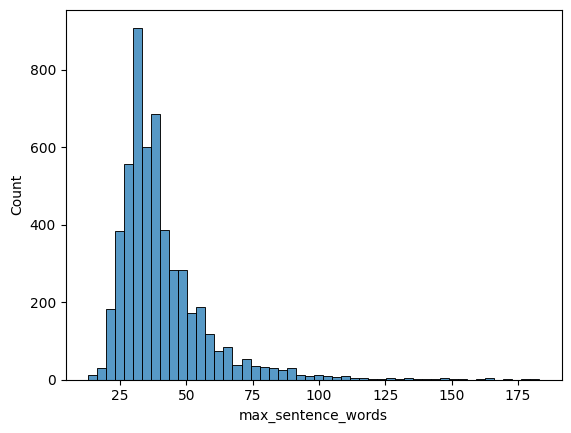

In [6]:
import seaborn as sns
sns.histplot(
    df["max_sentence_words"],
    bins=50
)

In [7]:
import pandas as pd
import stanza

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("dataset/dataset_step2_cleaned.csv", sep="|")

# =========================
# STANZA PIPELINE
# =========================
nlp = stanza.Pipeline(
    "id",
    processors="tokenize,lemma,pos,depparse",
    use_gpu=True,
    batch_size=64
)

# =========================
# AUDIT FUNCTION
# =========================
def stanza_audit(text):

    if not isinstance(text, str) or len(text.strip()) == 0:
        return {
            "n_sent": 0,
            "max_len": 0,
            "avg_len": 0,
            "no_verb_sent": 0
        }

    doc = nlp(text)
    sentences = doc.sentences

    if len(sentences) == 0:
        return {
            "n_sent": 0,
            "max_len": 0,
            "avg_len": 0,
            "no_verb_sent": 0
        }

    return {
        "n_sent": len(sentences),
        "max_len": max(len(s.words) for s in sentences),
        "avg_len": sum(len(s.words) for s in sentences) / len(sentences),
        "no_verb_sent": sum(
            1 for s in sentences
            if not any(w.upos == "VERB" for w in s.words)
        )
    }

# =========================
# RUN AUDIT
# =========================
results = df["Paragraf"].apply(stanza_audit).apply(pd.Series)

df_audit = pd.concat([df[["DocID"]], results], axis=1)

# =========================
# ADD FLAGS (IMPORTANT)
# =========================
df_audit["flag_long_sentence"] = df_audit["max_len"] > 80
df_audit["flag_no_verb"] = df_audit["no_verb_sent"] > 0
df_audit["flag_single_sentence"] = df_audit["n_sent"] == 1

# suspicious if 1 sentence but long text
df_audit["flag_boundary_error"] = (
    (df_audit["n_sent"] == 1) &
    (df_audit["max_len"] > 60)
)

# =========================
# SAVE CSV
# =========================
OUTPUT_PATH = "audit_stanza_docid.csv"

df_audit.to_csv(
    OUTPUT_PATH,
    index=False,
    sep="|"
)

print("AUDIT DONE ✔")
print("Saved to:", OUTPUT_PATH)
print(df_audit.head())

2026-06-24 22:19:36 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-06-24 22:19:36 INFO: Downloaded file to C:\Users\Danang ARA\stanza_resources\resources.json
2026-06-24 22:19:36 WARNING: Language id package default expects mwt, which has been added
2026-06-24 22:19:37 INFO: Loading these models for language: id (Indonesian):
| Processor | Package      |
----------------------------
| tokenize  | gsd          |
| mwt       | gsd          |
| pos       | gsd_charlm   |
| lemma     | gsd_nocharlm |
| depparse  | gsd_charlm   |

2026-06-24 22:19:37 INFO: Using device: cuda
2026-06-24 22:19:37 INFO: Loading: tokenize
2026-06-24 22:19:39 INFO: Loading: mwt
2026-06-24 22:19:39 INFO: Loading: pos
2026-06-24 22:19:40 INFO: Loading: lemma
2026-06-24 22:19:40 INFO: Loading: depparse
2026-06-24 22:19:40 INFO: Done loading processors!


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np

# ==========================================
# LOAD AUDIT RESULT
# ==========================================

df = pd.read_csv(
    "audit_stanza_docid.csv",
    sep="|"
)

# ==========================================
# COMPONENT SCORES
# ==========================================

# Sentence length health
df["sentence_score"] = (
    1 - np.minimum(df["max_len"] / 120, 1)
)

# Verb completeness
df["verb_score"] = (
    1 - (
        df["no_verb_sent"] /
        np.maximum(df["n_sent"], 1)
    )
)

# Boundary quality
df["boundary_score"] = np.where(
    df["flag_boundary_error"],
    0.30,
    1.00
)

# Segmentation quality
df["seg_score"] = np.where(
    (df["flag_single_sentence"]) &
    (df["max_len"] > 60),
    0.40,
    1.00
)

# ==========================================
# FINAL DQS
# ==========================================

df["DQS"] = (
    0.30 * df["sentence_score"] +
    0.30 * df["verb_score"] +
    0.30 * df["boundary_score"] +
    0.10 * df["seg_score"]
)

df["DQS"] = df["DQS"].clip(0, 1)

# ==========================================
# LABEL
# ==========================================

conditions = [
    df["DQS"] >= 0.85,
    df["DQS"] >= 0.70,
    df["DQS"] >= 0.50
]

choices = [
    "EXCELLENT",
    "GOOD",
    "FAIR"
]

df["DQS_Label"] = np.select(
    conditions,
    choices,
    default="POOR"
)

# ==========================================
# SAVE
# ==========================================

df.to_csv(
    "audit_stanza_dqs.csv",
    sep="|",
    index=False
)

print("\n===== DQS SUMMARY =====")
print(df["DQS"].describe())

print("\n===== LABEL DISTRIBUTION =====")
print(df["DQS_Label"].value_counts())

print("\nSaved:")
print("audit_stanza_dqs.csv")


===== DQS SUMMARY =====
count    5277.000000
mean        0.818607
std         0.122049
min         0.400000
25%         0.805000
50%         0.865000
75%         0.897500
max         0.960000
Name: DQS, dtype: float64

===== LABEL DISTRIBUTION =====
DQS_Label
EXCELLENT    3099
GOOD         1395
FAIR          634
POOR          149
Name: count, dtype: int64

Saved:
audit_stanza_dqs.csv


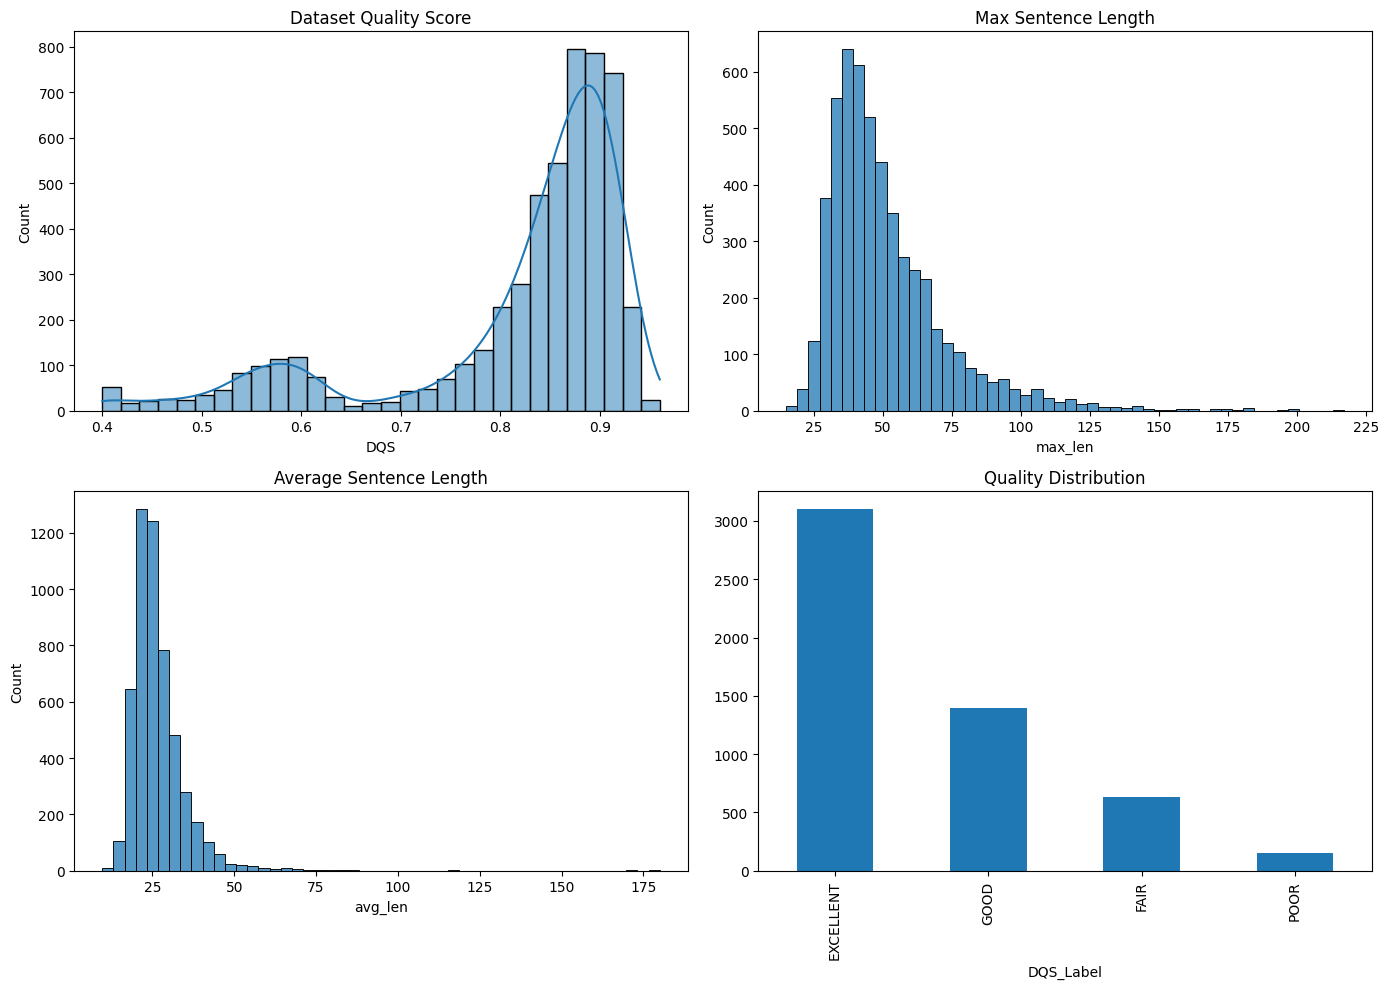


===== WORST 20 DOCUMENTS =====


,DocID,DQS,n_sent,max_len,avg_len,no_verb_sent
18,15020,0.4,4.0,145.0,64.750000,4.0
91,15100,0.4,9.0,123.0,31.333333,9.0
489,15538,0.4,15.0,173.0,45.266667,15.0
56,15062,0.4,6.0,135.0,53.833333,6.0
487,15536,0.4,8.0,172.0,52.125000,8.0
433,15474,0.4,4.0,148.0,61.250000,4.0
472,15519,0.4,5.0,137.0,68.000000,5.0
474,15521,0.4,7.0,163.0,56.285714,7.0
102,15111,0.4,8.0,158.0,42.375000,8.0
115,15124,0.4,9.0,121.0,31.444444,9.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "audit_stanza_dqs.csv",
    sep="|"
)

# ==========================================
# DASHBOARD
# ==========================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

# ------------------------
# DQS
# ------------------------

sns.histplot(
    df["DQS"],
    bins=30,
    kde=True,
    ax=axes[0,0]
)

axes[0,0].set_title(
    "Dataset Quality Score"
)

# ------------------------
# Sentence Length
# ------------------------

sns.histplot(
    df["max_len"],
    bins=50,
    ax=axes[0,1]
)

axes[0,1].set_title(
    "Max Sentence Length"
)

# ------------------------
# Average Length
# ------------------------

sns.histplot(
    df["avg_len"],
    bins=50,
    ax=axes[1,0]
)

axes[1,0].set_title(
    "Average Sentence Length"
)

# ------------------------
# Quality Labels
# ------------------------

df["DQS_Label"].value_counts().plot(
    kind="bar",
    ax=axes[1,1]
)

axes[1,1].set_title(
    "Quality Distribution"
)

plt.tight_layout()
plt.show()

# ==========================================
# TOP BAD DOCS
# ==========================================

print("\n===== WORST 20 DOCUMENTS =====")

display(
    df.sort_values(
        "DQS"
    )[
        [
            "DocID",
            "DQS",
            "n_sent",
            "max_len",
            "avg_len",
            "no_verb_sent"
        ]
    ].head(20)
)

In [ ]:
bad = df.sort_values("DQS").head(50)

bad[[
    "DocID",
    "DQS",
    "n_sent",
    "max_len",
    "avg_len",
    "no_verb_sent"
]]

,DocID,DQS,n_sent,max_len,avg_len,no_verb_sent
18,15020,0.4000,4.0,145.0,64.750000,4.0
91,15100,0.4000,9.0,123.0,31.333333,9.0
489,15538,0.4000,15.0,173.0,45.266667,15.0
56,15062,0.4000,6.0,135.0,53.833333,6.0
487,15536,0.4000,8.0,172.0,52.125000,8.0
433,15474,0.4000,4.0,148.0,61.250000,4.0
472,15519,0.4000,5.0,137.0,68.000000,5.0
474,15521,0.4000,7.0,163.0,56.285714,7.0
102,15111,0.4000,8.0,158.0,42.375000,8.0
115,15124,0.4000,9.0,121.0,31.444444,9.0


In [ ]:
#penyebab eror 
bad = df[df["DQS"] < 0.5]

print(bad["flag_boundary_error"].mean())
print(bad["flag_no_verb"].mean())
print(bad["flag_single_sentence"].mean())

0.020134228187919462
0.9798657718120806
0.020134228187919462


In [ ]:
# verifikasi kualitas tanda baca
bad = df[df["DQS"] < 0.5]

print(
    bad["max_len"].describe()
)

count    149.000000
mean     112.221477
std       28.373676
min       81.000000
25%       92.000000
50%      104.000000
75%      124.000000
max      217.000000
Name: max_len, dtype: float64


In [ ]:
import pandas as pd
import re

df = pd.read_csv("dataset/dataset_step2_cleaned.csv", sep="|")

# =========================
# PATTERN UTAMA
# =========================

MERGE_PATTERN = re.compile(
    r"\.[A-ZА-ЯA-Z]"  # titik langsung huruf besar
)

def detect_merge(text):
    if not isinstance(text, str):
        return 0

    return len(MERGE_PATTERN.findall(text))


def has_merge(text):
    return detect_merge(text) > 0

# =========================
# APPLY
# =========================

df["merge_error_count"] = df["Paragraf"].apply(detect_merge)
df["flag_merge_error"] = df["merge_error_count"] > 0

print(df["flag_merge_error"].value_counts())

flag_merge_error
False    4990
True      287
Name: count, dtype: int64


In [ ]:
import stanza

nlp = stanza.Pipeline(
    "id",
    processors="tokenize,lemma,pos,depparse",
    use_gpu=True
)

def stanza_sentence_count(text):
    if not isinstance(text, str):
        return 0

    doc = nlp(text)
    return len(doc.sentences)

# =========================
# APPLY SAMPLE (biar cepat)
# =========================

sample = df[df["flag_merge_error"] == True].head(200).copy()

sample["stanza_sent"] = sample["Paragraf"].apply(stanza_sentence_count)

# kasus penting:
# merge error tapi stanza cuma 1 sentence
sample["confirmed_merge"] = (
    (sample["merge_error_count"] > 0) &
    (sample["stanza_sent"] == 1)
)

print("CONFIRMED MERGE CASES:", sample["confirmed_merge"].mean())
print(sample[["DocID","merge_error_count","stanza_sent"]].head())

2026-06-20 11:49:05 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-06-20 11:49:05 INFO: Downloaded file to C:\Users\Danang ARA\stanza_resources\resources.json
2026-06-20 11:49:05 WARNING: Language id package default expects mwt, which has been added
2026-06-20 11:49:06 INFO: Loading these models for language: id (Indonesian):
| Processor | Package      |
----------------------------
| tokenize  | gsd          |
| mwt       | gsd          |
| pos       | gsd_charlm   |
| lemma     | gsd_nocharlm |
| depparse  | gsd_charlm   |

2026-06-20 11:49:06 INFO: Using device: cuda
2026-06-20 11:49:06 INFO: Loading: tokenize
2026-06-20 11:49:06 INFO: Loading: mwt
2026-06-20 11:49:06 INFO: Loading: pos
2026-06-20 11:49:07 INFO: Loading: lemma
2026-06-20 11:49:07 INFO: Loading: depparse
2026-06-20 11:49:08 INFO: Done loading processors!


CONFIRMED MERGE CASES: 0.0
     DocID  merge_error_count  stanza_sent
21   15023                  1            5
23   15026                  1           11
50   15053                  1            7
64   15070                  1            9
108  15117                  2            9


Rule-based punctuation heuristics overestimate sentence boundary errors, while neural sentence segmentation models (Stanza) demonstrate robustness against missing whitespace after period in Indonesian academic texts

In [ ]:
import pandas as pd
import nltk

# pastikan nltk punkt sudah diunduh
nltk.download("punkt")

# contoh dataframe
df = pd.read_csv("dataset/dataset_step2_cleaned.csv", sep="|")

# hitung jumlah kata per dokumen
df["Word_Count"] = (
    df["Paragraf"]
    .str.split()
    .str.len()
)

# hitung jumlah kalimat per dokumen
df["Sentence_Count"] = df["Paragraf"].apply(
    lambda x: len(nltk.sent_tokenize(str(x)))
)

# total kata dan kalimat
total_words = df["Word_Count"].sum()
total_sentences = df["Sentence_Count"].sum()

print("\n===== CORPUS SIZE =====")
print(f"Dokumen   : {len(df):,}")
print(f"Kalimat   : {total_sentences:,}")
print(f"Kata      : {total_words:,}")
print(f"Rata kata/kalimat : {total_words/total_sentences:.2f}")

# hitung rata-rata kata per kalimat per dokumen
df["Words_Per_Sentence"] = (
    df["Word_Count"] /
    df["Sentence_Count"].clip(lower=1)
)

print("\n===== SENTENCE STATS =====")
print(df["Sentence_Count"].describe())
print(df["Sentence_Count"].quantile([0.01,0.05,0.25,0.50,0.75,0.95,0.99]))

print("\n===== WORDS PER SENTENCE =====")
print(df["Words_Per_Sentence"].describe())


[nltk_data] Downloading package punkt to C:\Users\Danang
[nltk_data]     ARA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!



===== CORPUS SIZE =====
Dokumen   : 5,277
Kalimat   : 56,599
Kata      : 1,150,032
Rata kata/kalimat : 20.32

===== SENTENCE STATS =====
count    5277.000000
mean       10.725602
std         5.688773
min         1.000000
25%         7.000000
50%        10.000000
75%        12.000000
max        64.000000
Name: Sentence_Count, dtype: float64
0.01     3.0
0.05     5.0
0.25     7.0
0.50    10.0
0.75    12.0
0.95    21.0
0.99    35.0
Name: Sentence_Count, dtype: float64

===== WORDS PER SENTENCE =====
count    5277.000000
mean       21.975047
std         7.560860
min         7.750000
25%        17.833333
50%        20.619048
75%        24.333333
max       165.000000
Name: Words_Per_Sentence, dtype: float64


In [ ]:
outliers = df[df["Sentence_Count"] > 35].copy()

print("OUTLIER COUNT:", len(outliers))

OUTLIER COUNT: 47


In [ ]:
print(outliers[[
    "Word_Count",
    "Sentence_Count",
    "Words_Per_Sentence"
]].describe())

       Word_Count  Sentence_Count  Words_Per_Sentence
count   47.000000       47.000000           47.000000
mean   638.978723       42.234043           15.155191
std    139.043704        6.276986            2.673836
min    434.000000       36.000000           10.571429
25%    531.500000       38.000000           13.179688
50%    608.000000       40.000000           14.767442
75%    754.000000       45.000000           17.275012
max    968.000000       64.000000           23.583333


In [ ]:
import re

def classify_outlier(text):

    if not isinstance(text, str):
        return "null"

    text_low = text.lower()

    if "abstrak" in text_low and len(text.split()) < 50:
        return "header_noise"

    if "kata kunci" in text_low:
        return "keyword_noise"

    if re.search(r"\b(bab i|pendahuluan|latar belakang)\b", text_low):
        return "chapter_leak"

    if text.count(".") > 50:
        return "sentence_over_split"

    if len(text.split()) > 600:
        return "long_pdf_dump"

    return "unknown"


outliers["Outlier_Type"] = outliers["Paragraf"].apply(classify_outlier)

print(outliers["Outlier_Type"].value_counts())

Outlier_Type
unknown                22
long_pdf_dump          13
sentence_over_split    11
chapter_leak            1
Name: count, dtype: int64


In [ ]:
for i, row in outliers.sort_values("Sentence_Count", ascending=False).head(10).iterrows():
    print("\n" + "="*80)
    print("DocID:", row["DocID"])
    print("Sentences:", row["Sentence_Count"])
    print("Words:", row["Word_Count"])
    print("\n--- TEXT PREVIEW ---\n")
    print(row["Paragraf"][:1000])


DocID: 18518
Sentences: 64
Words: 839

--- TEXT PREVIEW ---

Telah kita ketahui bersama bahwa tujuan pembangunan nasional Indonesia adalah mencapai masyarakat yang adil dan makmur, merata meterial dan spiritual berdasar-kan Pancasila dan Undang-Undang Dasar 1945 dalam wadah Negara Kesatuan Republik Indonesia. Oleh karena sebagian besar wilayah Indonesia berada di kawasan pedesaan, maka titik berat pembangunan diprioritaskan pada wilayah pedesaan. Sejalan dengan hal tersebut maka pemerintah mulai tahun 1993 mengeluarkan Inpres No.5 Th 1993 tentang Inpres Desa Tertinggal yang mana merupakan program lanjutan dari program-program sebelumnya. Adapun makna In pres Desa Tertinggal adalah merupakan instruksi untuk mengkoordinasikan semua program pembangunan sektoral regional dan khususnya ditujukan untuk menanggulangi maslah kemiskinan, dan juga berupa pemberian dana seba-gai modal bagi masyarakat desa miskin untuk membangun dirinya sendiri melalui kegiatan sosial ekonomi yang dapat meningkat

In [ ]:
broken = outliers[
    (outliers["Sentence_Count"] > 35) &
    (outliers["Words_Per_Sentence"] < 15)
]

print("BROKEN ABSTRACTS:", len(broken))

BROKEN ABSTRACTS: 25


In [ ]:
outliers = df[df["Sentence_Count"] > 35]

outliers[["DocID", "Tahun", "Judul"]].sort_values("Tahun", ascending=False)

,DocID,Tahun,Judul
2521,18449,2010.0,"SKRIPSI PENGARUH PENGAWASAN, KEPEMIMPINAN DAN ..."
1977,17795,2009.0,SKRIPSI HUBUNGAN KERJA KEMANUSIAAN DAN TINGKAT...
1794,17566,2009.0,SKRIPSI PENGARUH PEMBINAAN DAN SPESIALISASI KE...
1800,17572,2006.0,SKRIPSI PENGARUH KEPEMIMPINAN DAN KEMAMPUAN KE...
2775,18830,2006.0,SKRIPSI PENGARUH KEPEMIMPINAN DAN KOORDINASI T...
2515,18441,2005.0,"SKRIPSI PENGARUH MOTIVASI KERJA, KOORDINASI DA..."
2899,18983,2005.0,"SKRIPSI PENGARUH PEMBAGIAN KERJA, PENGAWASAN D..."
2854,18928,2004.0,"SKRIPSI PENGARUH KEADAAN SOSIAL EKONOMI, MOTIV..."
1966,17779,2004.0,"SKRIPSI MOTIVASI, SPESIALISASI DAN SEMANGAT KE..."
1838,17624,2003.0,SKRIPSI PENGARUH KEPEMIMPINAN DAN MOTIVASI TER...


In [9]:
outliers = df[df["Sentence_Count"] > 35]

print(outliers["Tahun"].describe())
print("\nTop Years:")
print(outliers["Tahun"].value_counts().head(20))

count      71.000000
mean     2001.084507
std         5.255600
min      1990.000000
25%      2000.000000
50%      2001.000000
75%      2003.500000
max      2024.000000
Name: Tahun, dtype: float64

Top Years:
Tahun
2001.0    13
2000.0    12
2003.0     7
2006.0     5
2004.0     5
1992.0     4
2002.0     4
1996.0     3
1990.0     2
2008.0     2
1998.0     2
1995.0     2
1999.0     2
2009.0     2
2005.0     2
2024.0     1
1993.0     1
2010.0     1
1994.0     1
Name: count, dtype: int64


In [10]:
print("=== OUTLIER YEARS ===")
print(outliers["Tahun"].describe())

print("\n=== FULL CORPUS YEARS ===")
print(df["Tahun"].describe())

=== OUTLIER YEARS ===
count      71.000000
mean     2001.084507
std         5.255600
min      1990.000000
25%      2000.000000
50%      2001.000000
75%      2003.500000
max      2024.000000
Name: Tahun, dtype: float64

=== FULL CORPUS YEARS ===
count    5275.000000
mean     2016.020474
std        12.718442
min      1898.000000
25%      2003.000000
50%      2024.000000
75%      2025.000000
max      2026.000000
Name: Tahun, dtype: float64


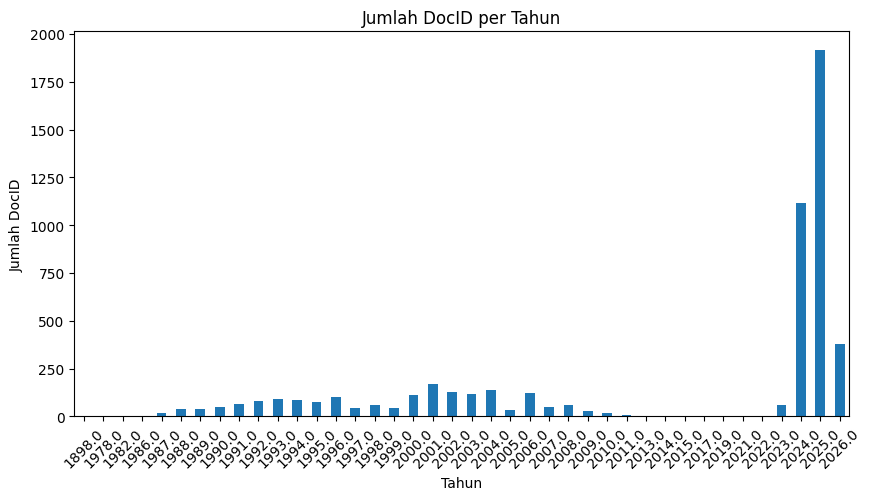

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataset/dataset_step2_cleaned.csv", sep="|", encoding="utf-8")

# Buat kolom Decade (opsional, kalau mau grouping per dekade)
df["Decade"] = (df["Tahun"] // 10) * 10

# Hitung jumlah DocID per Tahun
docid_per_tahun = df.groupby("Tahun")["DocID"].count()

# Plot hasil
docid_per_tahun.plot(kind="bar", figsize=(10,5))
plt.title("Jumlah DocID per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Jumlah DocID")
plt.xticks(rotation=45)
plt.show()


<Axes: xlabel='Tahun'>

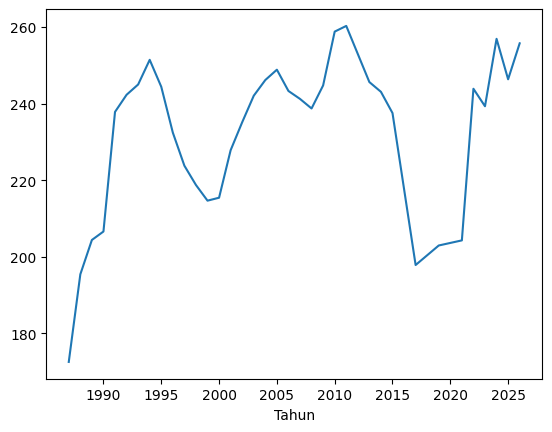

In [ ]:
df.groupby("Tahun")["Word_Count"].mean().rolling(5).mean().plot()

# EXPERIMEN

In [ ]:
import pandas as pd
import re

df = pd.read_csv("dataset/dataset_step2_cleaned.csv", sep="|")

# =========================
# 1. PROTECTED TOKENS
# =========================

PROTECTED = [
    r"\bDr\.",
    r"\bProf\.",
    r"\bM\.Si\b",
    r"\bS\.S\.I\b",
    r"\bPh\.D\b",
    r"\bU\.S\.",
    r"\bU\.K\.",
    r"\b[A-Z]{2,}\b",  # AI, NLP, WHO
]

def is_protected(text, idx):
    window = text[max(0, idx-15): idx+15]
    return any(re.search(p, window) for p in PROTECTED)

# =========================
# 2. MAIN DETECTOR (FOCUSED ON YOUR CASE)
# =========================

def detect_boundary_merge(text):
    text = str(text)

    # cari pola: titik langsung huruf kapital
    for m in re.finditer(r'\.([A-Z])', text):
        idx = m.start()

        # skip kalau protected
        if is_protected(text, idx):
            continue

        # ambil konteks sebelum titik
        before = text[max(0, idx-30):idx]

        # HEURISTIC 1: biasanya ada kata sebelum titik (word stuck)
        has_word_before = bool(re.search(r'[a-zA-Z]$', before))

        # HEURISTIC 2: setelah titik langsung kata panjang (bukan singkatan)
        after = text[idx+1:idx+15]
        next_word = re.match(r'[A-Z][a-z]+', after)

        if has_word_before and next_word:
            return True

    return False

# =========================
# 3. APPLY
# =========================

df["flag_boundary_merge"] = df["Paragraf"].apply(detect_boundary_merge)

# =========================
# 4. SAVE RESULT
# =========================

df[df["flag_boundary_merge"]].to_csv(
    "dataset/boundary_merge_errors.csv",
    index=False
)

print("DONE ✔ saved boundary_merge_errors.csv")
print(df["flag_boundary_merge"].value_counts())

DONE ✔ saved boundary_merge_errors.csv
flag_boundary_merge
False    5112
True      165
Name: count, dtype: int64


In [ ]:
import pandas as pd
import re
import stanza

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("dataset/dataset_step2_cleaned.csv", sep="|")

# =========================
# INIT STANZA
# =========================
nlp = stanza.Pipeline(
    "id",
    processors="tokenize,pos,lemma,depparse",
    use_gpu=True
)

# =========================
# PROTECTED ENTITIES
# =========================
PROTECTED = [
    r"\bDr\.", r"\bProf\.",
    r"\bM\.Si\b", r"\bPh\.D\b",
    r"\bS\.S\.I\b",
    r"\bU\.S\.", r"\bU\.K\.",
    r"\b[A-Z]{2,}\b"
]

def is_protected(text, idx):
    window = text[max(0, idx-10): idx+10]
    return any(re.search(p, window) for p in PROTECTED)

# =========================
# FIX SENTENCE BOUNDARY
# =========================
def fix_boundary(text):
    text = str(text)

    def repl(m):
        idx = m.start()
        if is_protected(text, idx):
            return m.group(0)
        return ". " + m.group(1)

    return re.sub(r'\.([A-Z])', repl, text)

# =========================
# STANZA SENTENCE SPLIT
# =========================
def stanza_sent_split(text):
    doc = nlp(str(text))
    return [sent.text for sent in doc.sentences]

# =========================
# PIPELINE
# =========================
df["clean_text"] = df["Paragraf"].apply(fix_boundary)

df["sentences_stanza_dirty"] = df["Paragraf"].apply(stanza_sent_split)
df["sentences_stanza_clean"] = df["clean_text"].apply(stanza_sent_split)

df["sent_count_dirty"] = df["sentences_stanza_dirty"].apply(len)
df["sent_count_clean"] = df["sentences_stanza_clean"].apply(len)

df["sentence_gain"] = df["sent_count_clean"] - df["sent_count_dirty"]

# =========================
# FLAG ERROR
# =========================
df["flag_boundary_error"] = df["sentence_gain"] > 0

print("DONE ✔ STANZA PIPELINE FINISHED")
print(df["flag_boundary_error"].value_counts())

2026-06-19 23:05:58 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-06-19 23:05:59 INFO: Downloaded file to C:\Users\Danang ARA\stanza_resources\resources.json
2026-06-19 23:05:59 WARNING: Language id package default expects mwt, which has been added
2026-06-19 23:05:59 INFO: Loading these models for language: id (Indonesian):
| Processor | Package      |
----------------------------
| tokenize  | gsd          |
| mwt       | gsd          |
| pos       | gsd_charlm   |
| lemma     | gsd_nocharlm |
| depparse  | gsd_charlm   |

2026-06-19 23:05:59 INFO: Using device: cuda
2026-06-19 23:05:59 INFO: Loading: tokenize
2026-06-19 23:05:59 INFO: Loading: mwt
2026-06-19 23:05:59 INFO: Loading: pos
2026-06-19 23:06:01 INFO: Loading: lemma
2026-06-19 23:06:01 INFO: Loading: depparse
2026-06-19 23:06:01 INFO: Done loading processors!


KeyboardInterrupt: 

In [ ]:
# =========================
# SAVE OUTPUT
# =========================

output_path = "dataset/stanza_boundary_output.csv"
df.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")

Saved to: dataset/stanza_boundary_output.csv
